In [253]:
import h5py
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

In [254]:
# data_path = "/home/korach/mich/${paths.data_dir}/julie-sim.h5"
name = "simulations-single_layer_single_source"
data_path = f"/media/RCPNAS/Data2/sengupta/inversion/mich/data/{name}.h5"

In [255]:
with h5py.File(data_path, "r") as file:
    bold = np.stack([file[layer]["bold"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    x = np.stack([file[layer]["x"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    s = np.stack([file[layer]["s"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    f = np.stack([file[layer]["f"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    v = np.stack([file[layer]["v"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    q = np.stack([file[layer]["q"][:50] for layer in file.keys() if "layer" in layer], axis=1)
    v_star = np.stack(
        [file[layer]["v_star"][:50] for layer in file.keys() if "layer" in layer], axis=1
    )
    q_star = np.stack(
        [file[layer]["q_star"][:50] for layer in file.keys() if "layer" in layer], axis=1
    )
    config = json.loads(file["meta"].attrs["config"])

    source_location = file["meta"]["sources"]["layer"][:50]
    source_pos = file["meta"]["sources"]["position"][:50]

In [256]:
print("Data shapes:")
print("BOLD:", bold.shape)
print("x:", x.shape)
print("s:", s.shape)
print("f:", f.shape)
print("v:", v.shape)
print("q:", q.shape)
print("v*:", v_star.shape)
print("q*:", q_star.shape)
print("Config:", config)

Data shapes:
BOLD: (5, 1, 100, 32, 32)
x: (5, 1, 100, 32, 32)
s: (5, 1, 100, 32, 32)
f: (5, 1, 100, 32, 32)
v: (5, 1, 100, 32, 32)
q: (5, 1, 100, 32, 32)
v*: (5, 1, 100, 32, 32)
q*: (5, 1, 100, 32, 32)
Config: {'num_simulations': 5, 'seed': 42, 'output_path': 'data/simulations-single_layer_single_source.h5', 'workers': 40, 'latent_downsample': 1, 'haemodynamic': {'alpha': 0.32, 'E0': 0.34, 'V0': 0.05, 'kappa': 0.65, 'gamma': 0.41}, 'acquisition': {'TE': 0.25, 'r0': 340, 'f0': 28.625, 'eps': 1e-32}, 'simulation': {'order': 'exact', 'grid_size': [32, 32], 'dt': 1.0, 'haemo_dt': 0.05, 'time_duration': 100, 'max_pulses': 10, 'pulse_type': 'rect', 'isi_min': 5, 'baseline_mode': 'random', 'amp_range': [0.3, 1.0], 'width_range': [2.0, 10.0], 'exp_decay_rate': 1.0, 'neural_SNR': inf, 'BOLD_SNR': 20.0, 'diffusion_coefficient_inter': 0.0, 'diffusion_coefficient_intra': 12.0, 'decay_rate': 1.0, 'tau_d': 1.0, 'num_layers': 1, 'min_active_layers': 1, 'max_active_layers': 1, 'layer_tau': 0.98, 'sour

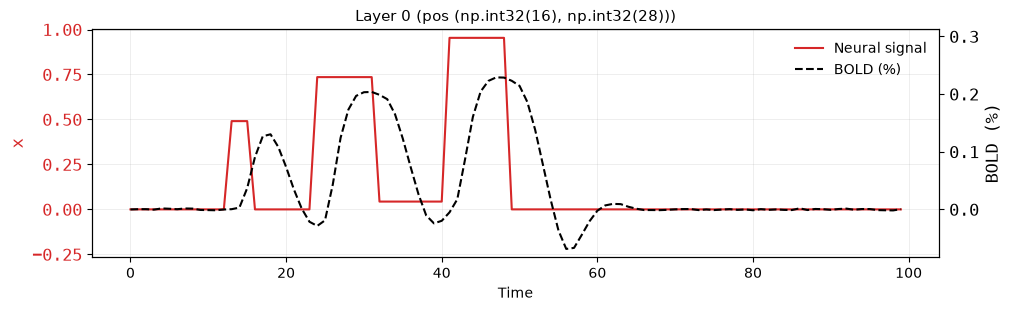

In [257]:
data_idx = np.random.randint(0, bold.shape[0])
slayer = source_location[data_idx]
spos = source_pos[data_idx]
n_layers = x.shape[1]

val_idx = np.where(slayer != -1)
ran_val_idx = np.random.choice(val_idx[0])


def layer_source_position(layer, fallback_idx):
    """Random active-source position for this layer; falls back to fallback_idx's position
    if the layer has no active source in this sample."""
    layer_events = np.where(slayer == layer)[0]
    if len(layer_events) == 0:
        return tuple(spos[fallback_idx])
    return tuple(spos[np.random.choice(layer_events)])


def layer_label(layer, n_layers):
    """Human-readable label for a layer index. Layer 0 is deepest, n_layers - 1 is most superficial."""
    if n_layers == 1:
        return f"Layer {layer}"
    if layer == 0:
        depth = "deep"
    elif layer == n_layers - 1:
        depth = "superficial"
    else:
        depth = "mid"
    return f"Layer {layer} ({depth})"


def align_yaxis(ax1, ax2):
    """Align the zero of ax2 with the zero of ax1, expanding limits as needed."""
    axes = (ax1, ax2)
    extrema = [a.get_ylim() for a in axes]
    tops = [extr[1] / (extr[1] - extr[0]) for extr in extrema]
    if tops[0] > tops[1]:
        axes, extrema, tops = (list(reversed(v)) for v in (axes, extrema, tops))

    tot_span = tops[1] + 1 - tops[0]

    b_new_t = extrema[0][0] + tot_span * (extrema[0][1] - extrema[0][0])
    t_new_b = extrema[1][1] - tot_span * (extrema[1][1] - extrema[1][0])
    axes[0].set_ylim(extrema[0][0], b_new_t)
    axes[1].set_ylim(t_new_b, extrema[1][1])


fig, axes = plt.subplots(
    nrows=n_layers,
    ncols=1,
    figsize=(10, 3 * n_layers),
    sharex=True,
    constrained_layout=True,
    squeeze=False,
)
axes = axes[:, 0]

for layer in range(n_layers):
    row = n_layers - 1 - layer  # deepest at bottom, most superficial at top
    ax = axes[row]
    pos = layer_source_position(layer, ran_val_idx)

    x_sig = x[data_idx, layer, :, *pos]
    bold_sig = bold[data_idx, layer, :, *pos]

    (l1,) = ax.plot(x_sig, color="tab:red", label="Neural signal")
    ax.set_ylabel("x", color="tab:red", fontsize=12, font="monospace")
    ax.tick_params(axis="y", labelcolor="tab:red", labelsize=12, labelfontfamily="monospace")
    ax.set_title(f"{layer_label(layer, n_layers)} (pos {pos})", fontsize=11)

    ax2 = ax.twinx()
    (l2,) = ax2.plot(bold_sig, color="black", ls="--", label="BOLD (%)")
    ax2.set_ylabel("BOLD (%)", color="black", fontsize=12, font="monospace")
    ax2.tick_params(axis="y", labelcolor="black", labelsize=12, labelfontfamily="monospace")

    align_yaxis(ax, ax2)

    ax.legend(handles=[l1, l2], loc="upper right", frameon=False)
    ax.grid(True, linewidth=0.5, alpha=0.3, which="both")

axes[-1].set_xlabel("Time")
plt.show()

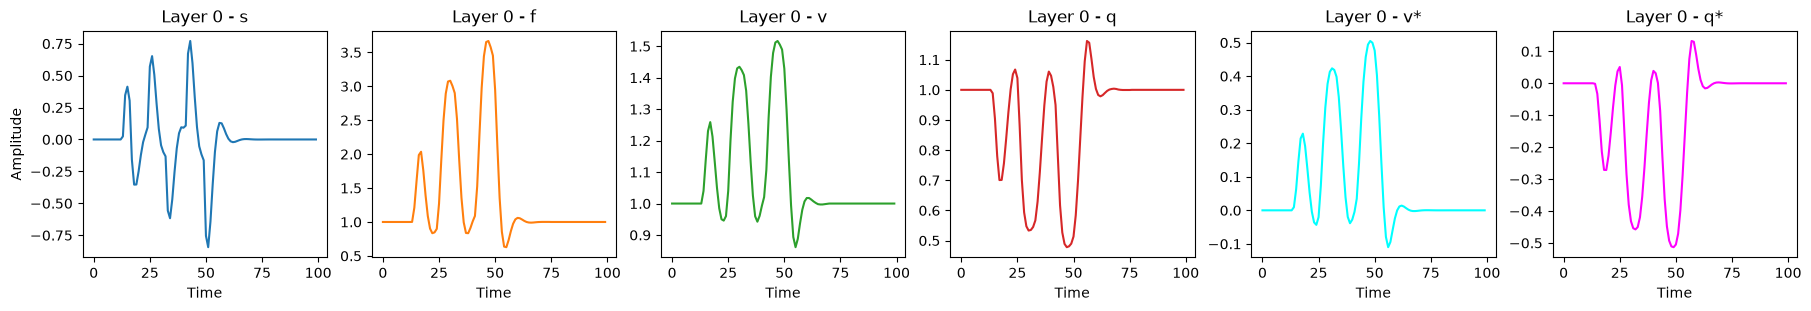

In [258]:
fig, ax = plt.subplots(
    nrows=n_layers, ncols=6, figsize=(18, 3 * n_layers), constrained_layout=True, squeeze=False
)

col_names = ["s", "f", "v", "q", "v*", "q*"]
col_data = [s, f, v, q, v_star, q_star]
col_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "cyan", "magenta"]

for i in range(n_layers):
    row = n_layers - 1 - i  # deepest at bottom
    pos = layer_source_position(i, ran_val_idx)

    for col, (name_, data, color) in enumerate(zip(col_names, col_data, col_colors)):
        ax[row, col].plot(data[data_idx, i, :, *pos], color=color)
        ax[row, col].set_title(f"{layer_label(i, n_layers)} - {name_}")

for r in range(n_layers):
    ax[r, 0].set_ylabel("Amplitude")
for c in range(6):
    ax[-1, c].set_xlabel("Time")

active_layers = sorted(set(slayer[slayer != -1].tolist()))
plt.show()

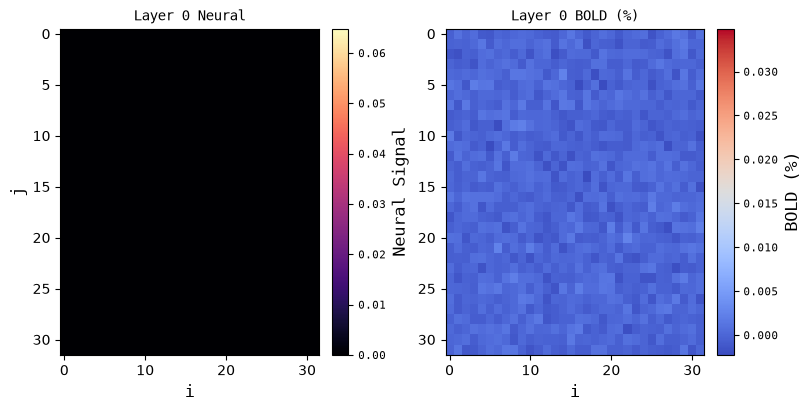

In [259]:
fig, ax = plt.subplots(
    nrows=n_layers, ncols=2, figsize=(8, 4 * n_layers), constrained_layout=True, squeeze=False
)

# Use full time dimension (100), not a single time index
bold_sig = bold[data_idx]  # shape: (layers, time, y, x)
neural_sig = x[data_idx]  # shape: (layers, time, y, x)

bold_min, bold_max = np.quantile(bold_sig, 0.01), np.quantile(bold_sig, 0.99)
neural_min, neural_max = np.quantile(neural_sig, 0.01), np.quantile(neural_sig, 0.99)

# active_layers = sorted(set(slayer[slayer != -1].tolist()))
# fig.suptitle(f"Source layers present: {active_layers}", fontsize=16, font="monospace")

# Keep image handles for animation updates, indexed by layer (not row)
img_neural = [None] * n_layers
img_bold = [None] * n_layers

for layer in range(n_layers):
    row = n_layers - 1 - layer  # deepest at bottom, most superficial at top

    n_im = ax[row, 0].imshow(
        neural_sig[layer, 0], aspect="auto", cmap="magma", vmin=neural_min, vmax=neural_max
    )
    b_im = ax[row, 1].imshow(
        bold_sig[layer, 0], aspect="auto", cmap="coolwarm", vmin=bold_min, vmax=bold_max
    )
    img_neural[layer] = n_im
    img_bold[layer] = b_im

    ax[row, 0].set_title(f"{layer_label(layer, n_layers)} Neural", fontsize=12, font="monospace")
    ax[row, 1].set_title(f"{layer_label(layer, n_layers)} BOLD (%)", fontsize=12, font="monospace")
    ax[row, 0].set_ylabel("j", fontsize=12, font="monospace")
    ax[row, 0].set_xlabel("i", fontsize=12, font="monospace")
    ax[row, 1].set_xlabel("i", fontsize=12, font="monospace")

    # One colorbar per column, per layer row
    n_cbar = fig.colorbar(n_im, ax=ax[row, 0], orientation="vertical")
    n_cbar.set_label("Neural Signal", fontsize=12, family="monospace")
    n_cbar.ax.tick_params(labelsize=8, labelfontfamily="monospace")

    b_cbar = fig.colorbar(b_im, ax=ax[row, 1], orientation="vertical")
    b_cbar.set_label("BOLD (%)", fontsize=12, family="monospace")
    b_cbar.ax.tick_params(labelsize=8, labelfontfamily="monospace")


def update_frame(t):
    for layer in range(n_layers):
        img_neural[layer].set_data(neural_sig[layer, t])
        img_bold[layer].set_data(bold_sig[layer, t])
    return img_neural + img_bold


ani = FuncAnimation(fig, update_frame, frames=bold_sig.shape[1], repeat=True)
plt.show()

In [260]:
# ani.save(f"{name}.gif", writer="pillow", fps=10)